In [5]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class MLP:
    def __init__(self, in_features, hidden_dim, out_features):
        self.hidden_weight = np.random.normal(loc=0, scale=1.0, size=(hidden_dim, in_features))
        self.bias1 = np.zeros((hidden_dim, 1))
        self.act_fn = sigmoid
        self.output_weight = np.random.normal(loc=0, scale=1.0, size=(out_features, hidden_dim))
        self.bias2 = np.zeros((out_features, 1))
    
    def forward(self, x):
        x = self.hidden_weight @ x.T + self.bias1
        x = self.act_fn(x)
        x = self.output_weight @ x + self.bias2
        x = self.act_fn(x)

        return x
    
    def backward(self, x, y, lr=1e-3):
        bsz = x.shape[0]
        z1 = self.hidden_weight @ x.T + self.bias1
        a1 = self.act_fn(z1)
        z2 = self.output_weight @ a1 + self.bias2
        a2 = self.act_fn(z2)
        delta2 = (a2 - y.T) * a2 * (1 - a2)
        delta1 = self.output_weight.T @ delta2 * a1 * (1 - a1)

        self.bias2 -= lr * delta2.sum(axis=1, keepdims=True) / bsz
        self.output_weight -= lr * (delta2 @ a1.T) / bsz
        self.bias1 -= lr * delta1.sum(axis=1, keepdims=True) / bsz
        self.hidden_weight -= lr * (delta1 @ x) / bsz

        return a2

X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

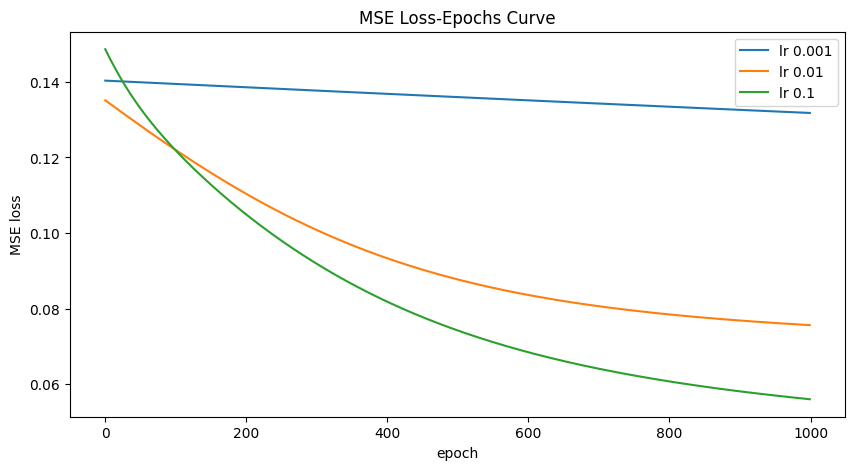

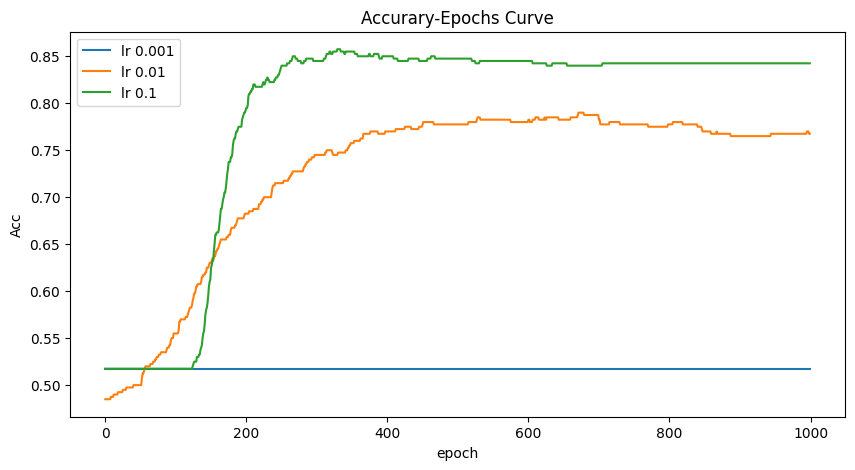

{0.001: np.float64(0.43), 0.01: np.float64(0.81), 0.1: np.float64(0.87)}


In [6]:
import matplotlib.pyplot as plt

def train(model, X, y, lr=1e-3, epochs=1000):
    losses = []
    accs = []
    for epoch in range(epochs):
        out = model.backward(X, y, lr=lr)
        loss = (0.5 * (out.T - y) ** 2).mean()
        acc = ((out.T > 0.5) == y).mean()
        losses.append(loss)
        accs.append(acc)

    return losses, accs

def eval(model, X, y):
    pred = model.forward(X)
    acc = ((pred.T > 0.5) == y).mean()

    return acc

loss = {}
acc = {}
eval_acc = {}
for lr in [1e-3, 1e-2, 1e-1]:
    model = MLP(in_features=X.shape[-1], hidden_dim=8, out_features=y.shape[-1])
    losses, accs = train(model, X_train, y_train, lr=lr, epochs=1000)
    loss[lr] = losses
    acc[lr] = accs
    eval_acc[lr] = eval(model, X_test, y_test)

plt.figure(figsize=(10, 5))
for lr, losses in loss.items():
    plt.plot(range(1000), losses, label=f"lr {lr}")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title(f"MSE Loss-Epochs Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for lr, accs in acc.items():
    plt.plot(range(1000), accs, label=f"lr {lr}")
plt.xlabel("epoch")
plt.ylabel("Acc")
plt.title(f"Accurary-Epochs Curve")
plt.legend()
plt.show()

print(eval_acc)